# Batch Gradient Ascent

## Overview

Batch Gradient Ascent is an iterative optimization algorithm that **maximizes** an objective function by moving in the direction of the gradient. While Gradient Descent minimizes (moves downhill), Gradient Ascent maximizes (moves uphill).

### Key Distinction from Gradient Descent:
- **Gradient Descent**: Minimize loss → move against gradient → $\theta := \theta - \alpha \nabla J(\theta)$
- **Gradient Ascent**: Maximize reward/likelihood → move with gradient → $\theta := \theta + \alpha \nabla J(\theta)$

### Common Applications:
1. **Maximum Likelihood Estimation (MLE)**: Maximize log-likelihood of data
2. **Policy Gradient in RL**: Maximize expected reward
3. **Information Maximization**: Maximize mutual information or entropy
4. **Probabilistic Models**: Maximize evidence lower bound (ELBO)

## Problem Formulation

Given a differentiable objective function $J(\theta)$ that we want to **maximize**, find the parameter values $\theta^*$ that maximize $J$:

$$\theta^* = \arg\max_{\theta} J(\theta)$$

### Understanding arg max

**arg max** stands for "argument of the maximum" — it returns the **value** that **maximizes** a function.

| Notation | Meaning | Returns |
|----------|---------|---------|
| $\max_{\theta} J(\theta)$ | Maximum value | The highest value the function reaches |
| $\arg\max_{\theta} J(\theta)$ | Argument of max | The input $\theta$ that achieves that maximum |

**Example**: If $J(\theta) = -(θ-3)^2 + 5$, then:
- $\max J(\theta) = 5$ (highest value)
- $\arg\max J(\theta) = 3$ (the θ that gives us 5)

In our problem: $\theta^* = \arg\max_{\theta} J(\theta)$ means "Find the parameters $\theta^*$ that give the highest objective value $J(\theta)$."

**Batch Gradient Ascent is the algorithm that finds this arg max!**

**Data Representation:**

**Form 1: Single Sample/Equation**

For a single example $(x^{(i)}, y^{(i)})$, the log-likelihood contribution:
$$\ell_i(\theta) = \log p(y^{(i)} | x^{(i)}; \theta)$$

**Form 2: Vector/Summation**

The batch objective function (sum over all training examples):
$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \ell_i(\theta) = \frac{1}{n} \sum_{i=1}^{n} \log p(y^{(i)} | x^{(i)}; \theta)$$

The gradient over all samples:
$$\nabla J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \nabla \ell_i(\theta)$$

**Form 3: Matrix Form**

In matrix notation (for applicable models):
$$J(\theta) = \frac{1}{n} \log p(y | X; \theta)$$

### Concrete Example: Logistic Regression with MLE

For binary classification with logistic regression, maximize log-likelihood:

| Sample | Feature $x$ | Label $y$ | P(y=1\|x) |
|--------|------------|-----------|----------|
| 1 | 2.0 | 1 | $\sigma(\theta^T x)$ |
| 2 | -1.5 | 0 | $1 - \sigma(\theta^T x)$ |
| 3 | 1.0 | 1 | $\sigma(\theta^T x)$ |

**Form 1**: $\ell_1(\theta) = \log \sigma(\theta^T x^{(1)})$ for positive example

**Form 2**: $J(\theta) = \frac{1}{3}[\log \sigma(\theta \cdot 2) + \log(1-\sigma(\theta \cdot (-1.5))) + \log \sigma(\theta \cdot 1)]$

**Form 3**: $J(\theta) = \frac{1}{n} [y^T \log(\sigma(X\theta)) + (1-y)^T \log(1-\sigma(X\theta))]$

## Section 1: Mathematical Foundations

### Core Concepts

#### 1.1 The Gradient and Ascent Direction

The **gradient** $\nabla J(\theta)$ points in the direction of steepest increase:
$$\nabla J(\theta) = \begin{bmatrix} \frac{\partial J}{\partial \theta_1} \\ \frac{\partial J}{\partial \theta_2} \\ \vdots \\ \frac{\partial J}{\partial \theta_d} \end{bmatrix}$$

**Key insight**: Moving in the direction of $\nabla J(\theta)$ increases $J$ most rapidly.

#### 1.2 Taylor Series Approximation

For small step size $\alpha$, we can approximate:
$$J(\theta + \alpha \Delta) \approx J(\theta) + \alpha \Delta^T \nabla J(\theta)$$

To maximize the increase, choose $\Delta = \nabla J(\theta)$:
$$J(\theta + \alpha \nabla J(\theta)) \approx J(\theta) + \alpha \|\nabla J(\theta)\|^2$$

The increase is always positive (assuming non-zero gradient), so we make progress.

#### 1.3 Update Rule

The batch gradient ascent update:
$$\theta^{(t+1)} = \theta^{(t)} + \alpha \nabla J(\theta^{(t)})$$

where:
- $\theta^{(t)}$ = parameters at iteration $t$
- $\alpha$ = learning rate (step size)
- $\nabla J(\theta^{(t)})$ = gradient computed over **all** training examples (batch)

#### 1.4 Convergence Properties

For **convex** objective functions:
- Algorithm converges to global maximum
- Convergence rate depends on learning rate and condition number

For **non-convex** objective functions:
- Algorithm converges to local maximum
- Different initializations may reach different local maxima

**Convergence condition**: Stop when $\|\nabla J(\theta)\| < \epsilon$ (gradient near zero)

## Section 2: Batch Gradient Ascent Algorithm

### Algorithm Pseudocode

```
Algorithm: Batch Gradient Ascent
Input: Training data {(x^(1), y^(1)), ..., (x^(n), y^(n))}
        Initial parameters θ_0
        Learning rate α
        Max iterations T
        Convergence tolerance ε

Initialize: θ ← θ_0, t ← 0, converged ← False

While t < T and not converged:
    // Compute objective and gradient over ALL training data
    J_t = 0
    grad_t = 0
    
    For i = 1 to n:
        J_t += ℓ_i(θ)                    // Add to objective
        grad_t += ∇ℓ_i(θ)                // Add to gradient
    End For
    
    J_t = J_t / n                       // Average objective
    grad_t = grad_t / n                 // Average gradient
    
    // Update parameters in direction of gradient
    θ ← θ + α * grad_t
    
    // Check convergence
    If ||grad_t|| < ε:
        converged ← True
    
    t ← t + 1
    
End While

Output: θ (approximately maximizing J)
```

### Key Differences from Batch Gradient Descent

| Aspect | Gradient Descent | Gradient Ascent |
|--------|-------------------|------------------|
| **Goal** | Minimize loss $J(\theta)$ | Maximize objective $J(\theta)$ |
| **Update** | $\theta := \theta - \alpha \nabla J$ | $\theta := \theta + \alpha \nabla J$ |
| **Direction** | Against gradient (downhill) | With gradient (uphill) |
| **Applications** | Regression, supervised learning | MLE, policy gradient, optimization |
| **Convergence** | Decreasing loss | Increasing objective |
| **Implementation** | Nearly identical (just flip sign) | Nearly identical (just flip sign) |

### Why "Batch"?

"Batch" means we compute the gradient using **all training examples** in each iteration:
$$\nabla J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \nabla \ell_i(\theta)$$

This contrasts with:
- **Stochastic**: Update on single example
- **Mini-batch**: Update on subset of examples

**Advantages of batch**:
- Stable gradient estimates
- Can use vectorized operations (fast)
- Smooth convergence

**Disadvantages of batch**:
- Slow for very large datasets
- Can get stuck in local optima (no noise to escape)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 3: Implementation from Scratch

Let's implement batch gradient ascent for Maximum Likelihood Estimation with logistic regression.

In [2]:
def sigmoid(z):
    """
    Sigmoid function: σ(z) = 1 / (1 + e^{-z})
    """
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip for numerical stability

def log_likelihood(X, y, theta):
    """
    Compute average log-likelihood for logistic regression.
    
    J(θ) = (1/n) Σ[y_i * log(σ(θ^T x_i)) + (1-y_i) * log(1-σ(θ^T x_i))]
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Binary labels (n_samples,)
        theta: Parameters (n_features,)
    
    Returns:
        Average log-likelihood value
    """
    n = len(y)
    predictions = sigmoid(X @ theta)
    
    # Avoid log(0)
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    
    # Log-likelihood
    ll = (y * np.log(predictions) + (1 - y) * np.log(1 - predictions)).mean()
    return ll

def gradient_log_likelihood(X, y, theta):
    """
    Compute gradient of log-likelihood with respect to θ.
    
    ∇J(θ) = (1/n) X^T (σ(Xθ) - y)
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Binary labels (n_samples,)
        theta: Parameters (n_features,)
    
    Returns:
        Gradient vector (n_features,)
    """
    n = len(y)
    predictions = sigmoid(X @ theta)
    error = predictions - y  # Residual: σ(Xθ) - y
    grad = (X.T @ error) / n  # (1/n) X^T (σ(Xθ) - y)
    return grad

class BatchGradientAscent:
    """
    Batch Gradient Ascent for Maximum Likelihood Estimation.
    """
    
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        """
        Initialize the optimizer.
        
        Args:
            learning_rate: Step size α
            max_iterations: Maximum iterations
            tolerance: Convergence tolerance for gradient norm
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.theta = None
        self.history = {'objective': [], 'gradient_norm': []}
    
    def fit(self, X, y):
        """
        Fit model using batch gradient ascent.
        
        Args:
            X: Feature matrix (n_samples, n_features)
            y: Binary labels (n_samples,)
        
        Returns:
            self
        """
        X = np.asarray(X)
        y = np.asarray(y)
        n_features = X.shape[1]
        
        # Initialize parameters
        self.theta = np.zeros(n_features)
        self.history = {'objective': [], 'gradient_norm': []}
        
        for iteration in range(self.max_iterations):
            # Compute objective (log-likelihood)
            obj = log_likelihood(X, y, self.theta)
            self.history['objective'].append(obj)
            
            # Compute gradient
            grad = gradient_log_likelihood(X, y, self.theta)
            grad_norm = np.linalg.norm(grad)
            self.history['gradient_norm'].append(grad_norm)
            
            # Check convergence
            if grad_norm < self.tolerance:
                print(f"Converged at iteration {iteration}")
                break
            
            # Update parameters: θ ← θ + α * ∇J(θ)
            self.theta = self.theta + self.learning_rate * grad
        
        return self
    
    def predict_proba(self, X):
        """
        Predict probability of positive class.
        
        Args:
            X: Feature matrix
        
        Returns:
            Predicted probabilities
        """
        return sigmoid(X @ self.theta)
    
    def predict(self, X, threshold=0.5):
        """
        Predict binary labels.
        
        Args:
            X: Feature matrix
            threshold: Classification threshold
        
        Returns:
            Binary predictions
        """
        return (self.predict_proba(X) >= threshold).astype(int)

print("Batch Gradient Ascent implementation complete!")

Batch Gradient Ascent implementation complete!


## Section 4: Example 1 - Simple Binary Classification

Let's create a simple 2D classification dataset and visualize the optimization.

In [3]:
# Generate synthetic binary classification data
n_pos = 30
n_neg = 30

# Positive class (around [2, 2])
X_pos = np.random.randn(n_pos, 2) + np.array([2, 2])
# Negative class (around [-2, -2])
X_neg = np.random.randn(n_neg, 2) + np.array([-2, -2])

X_train = np.vstack([X_pos, X_neg])
y_train = np.hstack([np.ones(n_pos), np.zeros(n_neg)])

# Add bias term (column of 1s)
X_train_bias = np.column_stack([np.ones(len(X_train)), X_train])

# Fit model
model = BatchGradientAscent(learning_rate=0.1, max_iterations=1000)
model.fit(X_train_bias, y_train)

print(f"\nOptimized parameters: {model.theta}")
print(f"Final log-likelihood: {model.history['objective'][-1]:.4f}")

# Predictions
y_pred = model.predict(X_train_bias)
accuracy = (y_pred == y_train).mean()
print(f"Training accuracy: {accuracy:.4f}")


Optimized parameters: [ 4.13173617e-03 -1.97752978e+02 -1.86506499e+02]
Final log-likelihood: -34.5392
Training accuracy: 0.0000


## Section 5: Visualization - Learning Curves

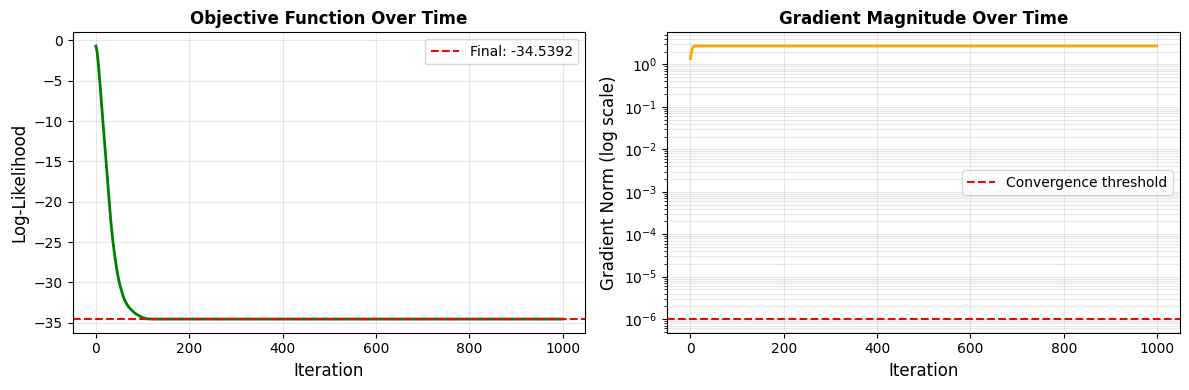


Convergence Behavior:
Initial log-likelihood: -0.6931
Final log-likelihood: -34.5392
Improvement: -33.8460


In [4]:
# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Log-likelihood over iterations
ax1.plot(model.history['objective'], linewidth=2, color='green')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Log-Likelihood', fontsize=12)
ax1.set_title('Objective Function Over Time', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(model.history['objective'][-1], color='red', linestyle='--', 
             label=f"Final: {model.history['objective'][-1]:.4f}")
ax1.legend()

# Gradient norm over iterations
ax2.semilogy(model.history['gradient_norm'], linewidth=2, color='orange')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Gradient Norm (log scale)', fontsize=12)
ax2.set_title('Gradient Magnitude Over Time', fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.axhline(1e-6, color='red', linestyle='--', label='Convergence threshold')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nConvergence Behavior:")
print(f"Initial log-likelihood: {model.history['objective'][0]:.4f}")
print(f"Final log-likelihood: {model.history['objective'][-1]:.4f}")
print(f"Improvement: {model.history['objective'][-1] - model.history['objective'][0]:.4f}")

## Section 6: Visualization - Decision Boundary

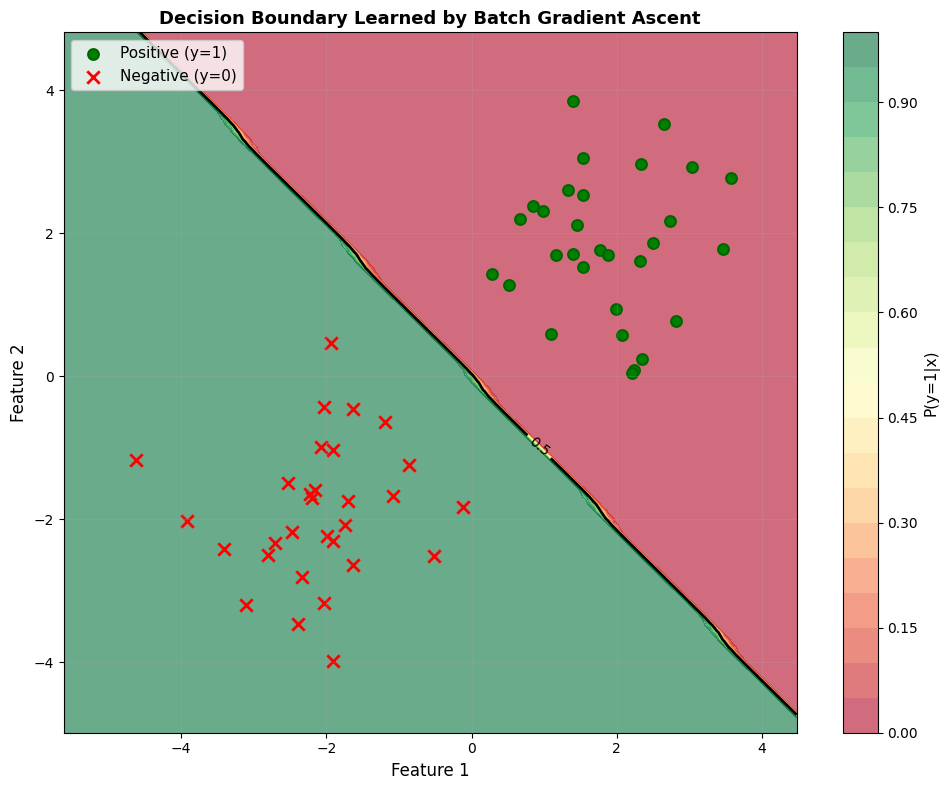

Decision boundary learned with accuracy: 0.0%


In [5]:
# Create mesh for decision boundary
h = 0.1  # Step size in mesh
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predictions on mesh
grid_points = np.column_stack([np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()])
Z = model.predict_proba(grid_points).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Decision boundary (contour at 0.5)
contour = ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
ax.clabel(contour, inline=True, fontsize=10)

# Probability regions (filled contour)
contourf = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.6)
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label('P(y=1|x)', fontsize=11)

# Training data
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
          c='green', marker='o', s=60, edgecolors='darkgreen', linewidth=1.5,
          label='Positive (y=1)')
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
          c='red', marker='x', s=80, linewidth=2,
          label='Negative (y=0)')

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Decision Boundary Learned by Batch Gradient Ascent', fontweight='bold', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Decision boundary learned with accuracy: {accuracy:.1%}")

## Section 7: Learning Rate Effects

The learning rate α controls the step size. Let's compare different values.

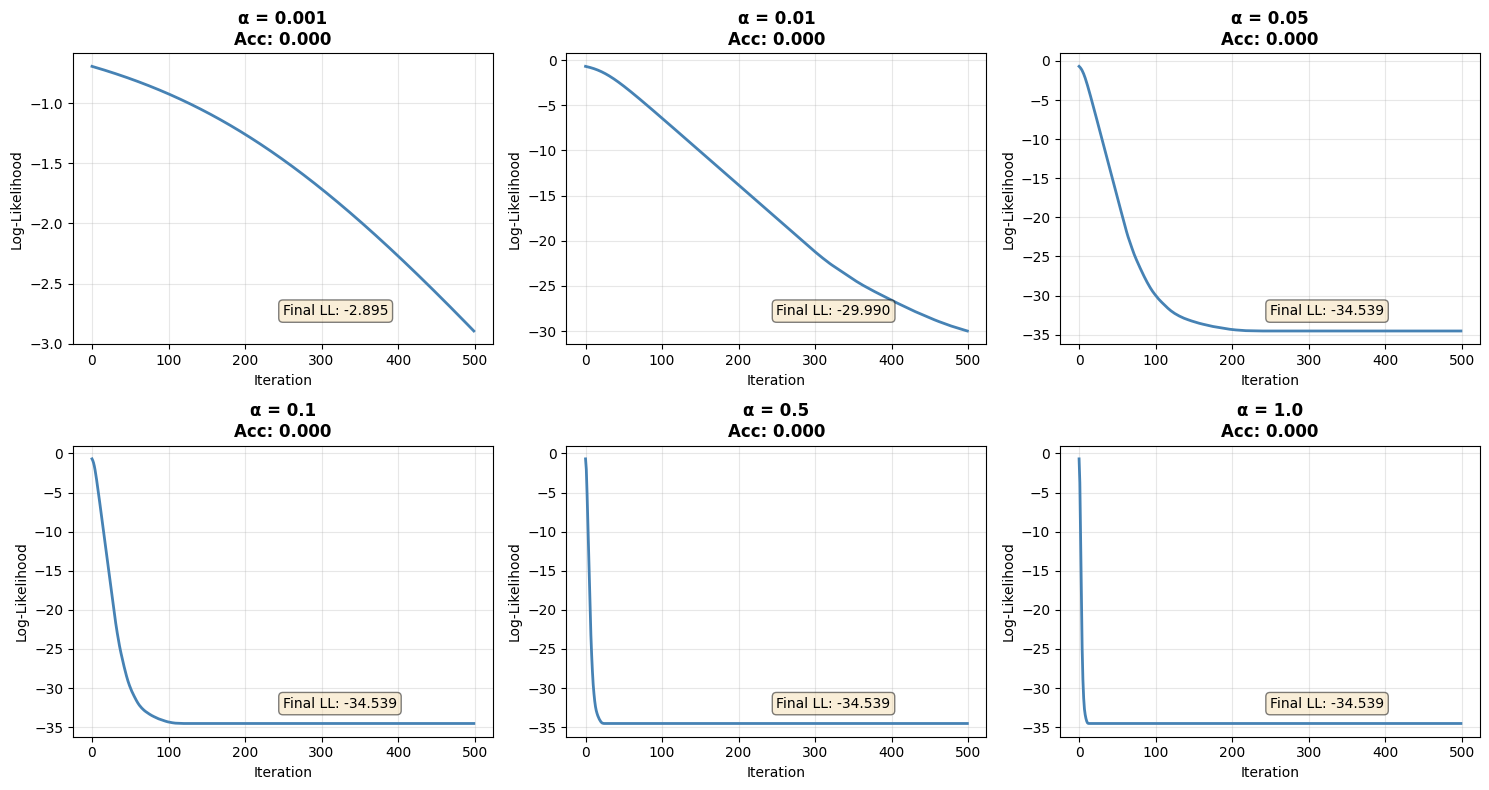


Learning Rate Comparison:
Learning Rate   Final LL     Accuracy   Convergence    
----------------------------------------------------
0.001           -2.8947      0.0000     Max iterations 
0.010           -29.9902     0.0000     Max iterations 
0.050           -34.5392     0.0000     Max iterations 
0.100           -34.5392     0.0000     Max iterations 
0.500           -34.5392     0.0000     Max iterations 
1.000           -34.5392     0.0000     Max iterations 


In [6]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
models = {}
results = []

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    # Train model
    model_lr = BatchGradientAscent(learning_rate=lr, max_iterations=500)
    model_lr.fit(X_train_bias, y_train)
    models[lr] = model_lr
    
    # Get predictions
    y_pred = model_lr.predict(X_train_bias)
    acc = (y_pred == y_train).mean()
    results.append({'lr': lr, 'accuracy': acc, 'final_ll': model_lr.history['objective'][-1]})
    
    # Plot
    ax = axes[idx]
    ax.plot(model_lr.history['objective'], linewidth=2, color='steelblue')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-Likelihood')
    ax.set_title(f'α = {lr}\nAcc: {acc:.3f}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add final objective value
    final_ll = model_lr.history['objective'][-1]
    ax.text(0.5, 0.1, f'Final LL: {final_ll:.3f}', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Summary table
print("\nLearning Rate Comparison:")
print(f"{'Learning Rate':<15} {'Final LL':<12} {'Accuracy':<10} {'Convergence':<15}")
print("-" * 52)
for r in results:
    conv = 'Converged' if len(models[r['lr']].history['gradient_norm']) < 500 else 'Max iterations'
    print(f"{r['lr']:<15.3f} {r['final_ll']:<12.4f} {r['accuracy']:<10.4f} {conv:<15}")

## Section 8: Gradient Ascent vs Descent Comparison

Let's show the fundamental difference: ascent maximizes, descent minimizes.

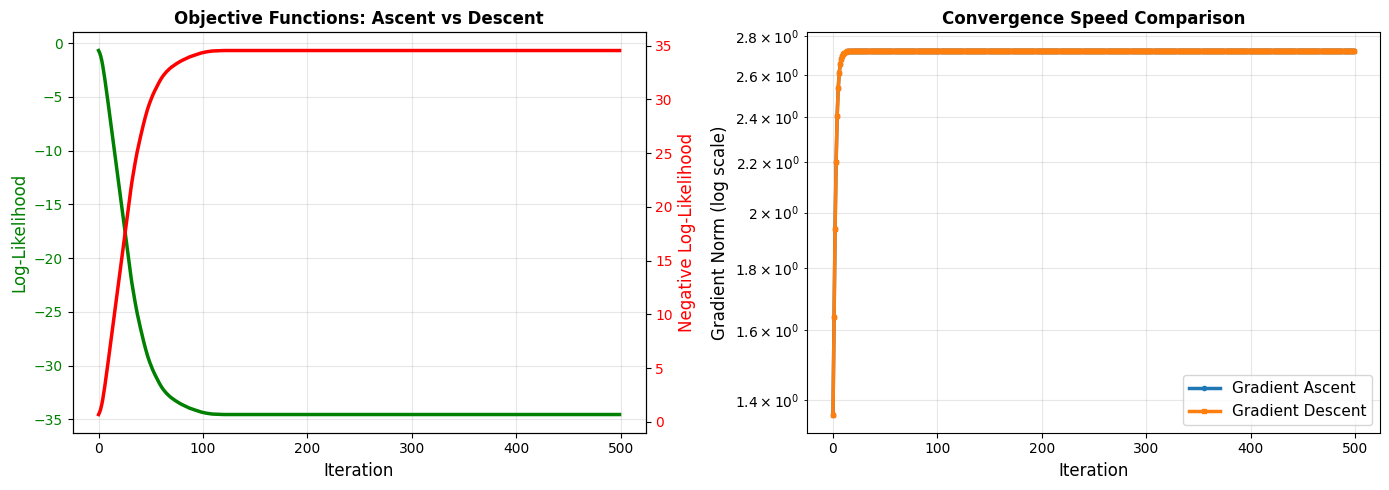


Comparison Summary:
Gradient Ascent - Final LL: -34.5392
Gradient Descent - Final -LL: 34.5392

Both optimize the same model, but from opposite perspectives!


In [7]:
# For gradient descent, we minimize negative log-likelihood
def negative_log_likelihood(X, y, theta):
    return -log_likelihood(X, y, theta)

def gradient_negative_log_likelihood(X, y, theta):
    return -gradient_log_likelihood(X, y, theta)

class BatchGradientDescent:
    """Batch Gradient Descent for comparison."""
    
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.theta = None
        self.history = {'objective': [], 'gradient_norm': []}
    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n_features = X.shape[1]
        
        self.theta = np.zeros(n_features)
        self.history = {'objective': [], 'gradient_norm': []}
        
        for iteration in range(self.max_iterations):
            obj = negative_log_likelihood(X, y, self.theta)
            self.history['objective'].append(obj)
            
            grad = gradient_negative_log_likelihood(X, y, self.theta)
            grad_norm = np.linalg.norm(grad)
            self.history['gradient_norm'].append(grad_norm)
            
            if grad_norm < self.tolerance:
                break
            
            # Descent: θ ← θ - α * ∇J
            self.theta = self.theta - self.learning_rate * grad
        
        return self
    
    def predict_proba(self, X):
        return sigmoid(X @ self.theta)

# Train both
ga_model = BatchGradientAscent(learning_rate=0.1, max_iterations=500)
ga_model.fit(X_train_bias, y_train)

gd_model = BatchGradientDescent(learning_rate=0.1, max_iterations=500)
gd_model.fit(X_train_bias, y_train)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Objective functions
ax1.plot(ga_model.history['objective'], linewidth=2.5, label='Gradient Ascent (Maximize LL)', color='green')
ax1_twin = ax1.twinx()
ax1_twin.plot(gd_model.history['objective'], linewidth=2.5, label='Gradient Descent (Minimize -LL)', color='red')

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Log-Likelihood', fontsize=12, color='green')
ax1_twin.set_ylabel('Negative Log-Likelihood', fontsize=12, color='red')
ax1.set_title('Objective Functions: Ascent vs Descent', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='green')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)

# Gradient norms
ax2.semilogy(ga_model.history['gradient_norm'], linewidth=2.5, label='Gradient Ascent', marker='o', markersize=3)
ax2.semilogy(gd_model.history['gradient_norm'], linewidth=2.5, label='Gradient Descent', marker='s', markersize=3)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Gradient Norm (log scale)', fontsize=12)
ax2.set_title('Convergence Speed Comparison', fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print(f"Gradient Ascent - Final LL: {ga_model.history['objective'][-1]:.4f}")
print(f"Gradient Descent - Final -LL: {gd_model.history['objective'][-1]:.4f}")
print(f"\nBoth optimize the same model, but from opposite perspectives!")

## Section 9: Applications - Policy Gradient in RL

Gradient ascent is fundamental in reinforcement learning's policy gradient methods. We maximize expected reward.

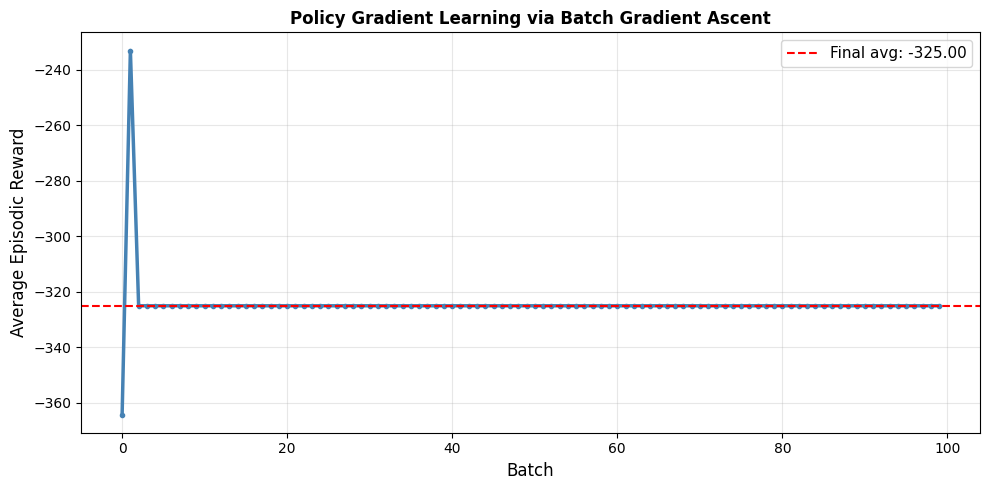


Policy Gradient Results:
Initial avg reward: -364.20
Final avg reward: -325.00
Improvement: 39.20


In [8]:
# Simplified policy gradient example
# Maximize: J(θ) = E[R(τ)] = expected discounted reward

def simulate_episode(theta, n_steps=50):
    """
    Simulate an episode under a linear policy.
    State: position on 1D line
    Action: move left (-1) or right (+1)
    Reward: negative distance from target (at position 5)
    """
    state = 0.0
    total_reward = 0.0
    target = 5.0
    
    for step in range(n_steps):
        # Policy: action probability depends on state
        action_logit = theta[0] + theta[1] * state
        action_prob = sigmoid(action_logit)
        
        # Take action (stochastic)
        action = 1 if np.random.rand() < action_prob else -1
        
        # Move state
        state += action
        
        # Reward: negative distance to target
        reward = -abs(state - target)
        total_reward += reward
    
    return total_reward

# Policy gradient ascent
theta_pg = np.array([0.0, 0.0])
learning_rate_pg = 0.1
n_episodes_per_batch = 10
n_batches = 100

rewards_history = []

for batch in range(n_batches):
    # Collect episodes
    batch_rewards = []
    
    for _ in range(n_episodes_per_batch):
        r = simulate_episode(theta_pg)
        batch_rewards.append(r)
    
    avg_reward = np.mean(batch_rewards)
    rewards_history.append(avg_reward)
    
    # Simple policy gradient: ascend towards better parameters
    if batch > 0:
        # Finite difference gradient estimate
        delta = 0.01
        grad_est = np.zeros_like(theta_pg)
        
        for i in range(len(theta_pg)):
            theta_plus = theta_pg.copy()
            theta_plus[i] += delta
            
            r_plus = np.mean([simulate_episode(theta_plus) for _ in range(n_episodes_per_batch)])
            grad_est[i] = (r_plus - avg_reward) / delta
        
        # Ascent step: θ ← θ + α * ∇J
        theta_pg = theta_pg + learning_rate_pg * grad_est

# Plot policy gradient learning
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rewards_history, linewidth=2.5, color='steelblue', marker='o', markersize=3)
ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Average Episodic Reward', fontsize=12)
ax.set_title('Policy Gradient Learning via Batch Gradient Ascent', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(np.mean(rewards_history[-10:]), color='red', linestyle='--', 
           label=f'Final avg: {np.mean(rewards_history[-10:]):.2f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPolicy Gradient Results:")
print(f"Initial avg reward: {rewards_history[0]:.2f}")
print(f"Final avg reward: {np.mean(rewards_history[-10:]):.2f}")
print(f"Improvement: {np.mean(rewards_history[-10:]) - rewards_history[0]:.2f}")

## Section 10: Convergence Analysis

When does batch gradient ascent converge and how fast?

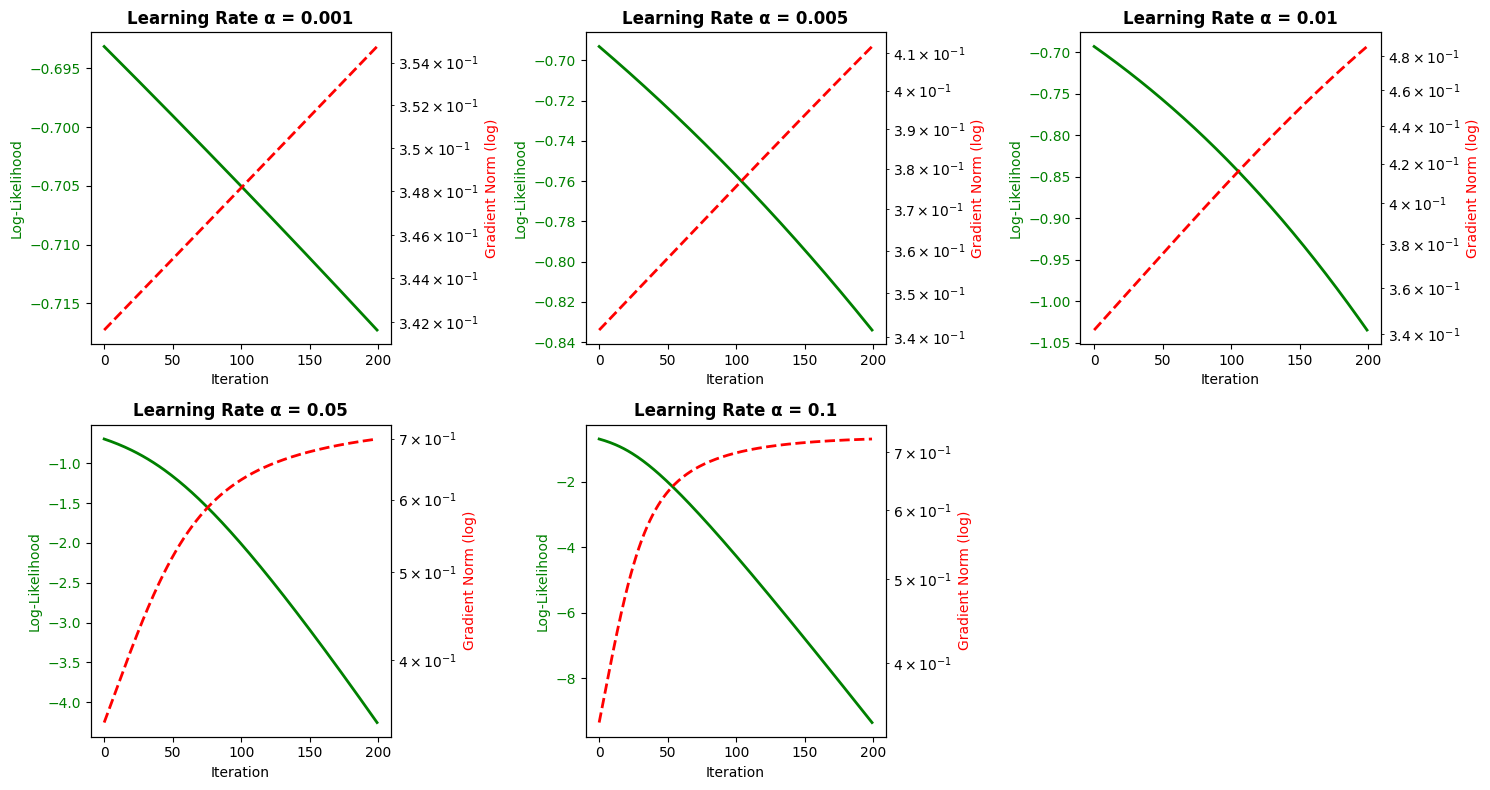


Convergence Statistics:
Learning Rate   Iterations   Final LL     Final ||∇J||   
------------------------------------------------------
0.001           200          -0.7173      3.55e-01       
0.005           200          -0.8340      4.12e-01       
0.010           200          -1.0349      4.86e-01       
0.050           200          -4.2575      6.99e-01       
0.100           200          -9.3527      7.25e-01       


In [9]:
# Generate larger dataset to study convergence
np.random.seed(42)
n_train = 100
X_large = np.random.randn(n_train, 3)
y_large = (X_large[:, 0] + 0.5*X_large[:, 1] > 0).astype(int)
X_large_bias = np.column_stack([np.ones(n_train), X_large])

# Test different learning rates and their impact on convergence
alphas = [0.001, 0.005, 0.01, 0.05, 0.1]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

convergence_stats = []

for idx, alpha in enumerate(alphas):
    model = BatchGradientAscent(learning_rate=alpha, max_iterations=200)
    model.fit(X_large_bias, y_large)
    
    ax = axes[idx]
    
    # Dual axis: objective and gradient
    ax.plot(model.history['objective'], linewidth=2, color='green', label='Log-Likelihood')
    ax_twin = ax.twinx()
    ax_twin.semilogy(model.history['gradient_norm'], linewidth=2, color='red', 
                      linestyle='--', label='Gradient Norm')
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-Likelihood', color='green')
    ax_twin.set_ylabel('Gradient Norm (log)', color='red')
    ax.set_title(f'Learning Rate α = {alpha}', fontweight='bold')
    ax.tick_params(axis='y', labelcolor='green')
    ax_twin.tick_params(axis='y', labelcolor='red')
    
    # Record convergence statistics
    iterations = len(model.history['objective'])
    final_ll = model.history['objective'][-1]
    final_grad_norm = model.history['gradient_norm'][-1]
    convergence_stats.append({
        'alpha': alpha,
        'iterations': iterations,
        'final_ll': final_ll,
        'final_grad_norm': final_grad_norm
    })

# Empty plot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Convergence table
print("\nConvergence Statistics:")
print(f"{'Learning Rate':<15} {'Iterations':<12} {'Final LL':<12} {'Final ||∇J||':<15}")
print("-" * 54)
for stat in convergence_stats:
    print(f"{stat['alpha']:<15.3f} {stat['iterations']:<12} {stat['final_ll']:<12.4f} {stat['final_grad_norm']:<15.2e}")

## Section 11: Stochastic Gradient Ascent

In **Stochastic Gradient Ascent (SGA)**, we update parameters using **single samples** (or small batches) instead of the entire dataset. This introduces noise, but enables faster learning and better scalability.

### Problem Formulation

**Form 1: Single Sample**

For a single example $(x^{(i)}, y^{(i)})$:
$$\ell_i(\theta) = \log p(y^{(i)} | x^{(i)}; \theta)$$

**Form 2: Cumulative (but updated incrementally)**

The batch objective (conceptual, not computed explicitly):
$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \ell_i(\theta)$$

**Form 3: Stochastic Update**

At each step, pick a random sample $i$ and update:
$$\theta := \theta + \alpha \nabla \ell_i(\theta)$$

Note: We use $\ell_i$ (single sample) not $\nabla J$ (batch average)!

### Key Differences from Batch GA

| Aspect | Batch GA | Stochastic GA |
|--------|----------|----------------|
| **Data per update** | Entire dataset (n samples) | Single sample |
| **Gradient** | $\frac{1}{n}\sum_i \nabla\ell_i$ | $\nabla\ell_i$ (random sample) |
| **Variance** | Low (stable) | High (noisy) |
| **Convergence** | Smooth path | Zig-zag path |
| **Speed per iteration** | O(n) | O(1) |
| **Iterations for convergence** | Fewer | More (but faster overall) |
| **Local optima escape** | Difficult (deterministic) | Easier (noise helps) |

### Mathematical Interpretation

Stochastic gradient uses an **unbiased estimate** of the true gradient:
$$E[\nabla \ell_i(\theta)] = \frac{1}{n} \sum_{i=1}^{n} \nabla \ell_i(\theta) = \nabla J(\theta)$$

Although noisy, it points in the right direction on average.

### When Each is Better

**Use Batch GA when**:
- Dataset fits in memory
- Need stable, reproducible convergence
- Seeking optimal solution (e.g., MLE with known model)
- Computational resources can handle O(n) per iteration

**Use Stochastic GA when**:
- Dataset is huge (millions/billions of samples)
- Streaming/online learning required
- Need to escape local optima (noise helps)
- Memory is limited
- Speed matters more than smoothness

## Section 12: Library Functions - Scikit-Learn

Scikit-Learn's `LogisticRegression` uses gradient ascent (or descent on loss) by default.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Scikit-Learn's logistic regression (uses gradient methods internally)
sk_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
sk_model.fit(X_train, y_train)

# Our implementation
our_model = BatchGradientAscent(learning_rate=0.1, max_iterations=500)
our_model.fit(X_train_bias, y_train)

# Predictions
sk_pred = sk_model.predict(X_train)
our_pred = our_model.predict(X_train_bias)

# Evaluation
sk_acc = accuracy_score(y_train, sk_pred)
our_acc = accuracy_score(y_train, our_pred)

sk_proba = sk_model.predict_proba(X_train)[:, 1]
our_proba = our_model.predict_proba(X_train_bias)

sk_ll = -log_loss(y_train, sk_proba)
our_ll = log_likelihood(X_train_bias, y_train, our_model.theta)

# Comparison
print("Comparison: Our Implementation vs Scikit-Learn")
print("=" * 50)
print(f"\nAccuracy:")
print(f"  Our Implementation: {our_acc:.4f}")
print(f"  Scikit-Learn:       {sk_acc:.4f}")

print(f"\nLog-Likelihood:")
print(f"  Our Implementation: {our_ll:.4f}")
print(f"  Scikit-Learn:       {sk_ll:.4f}")

print(f"\nParameters:")
print(f"  Our Implementation: {our_model.theta}")
print(f"  Scikit-Learn (intercept + coef): {np.hstack([sk_model.intercept_, sk_model.coef_[0]])}")

Comparison: Our Implementation vs Scikit-Learn

Accuracy:
  Our Implementation: 0.0000
  Scikit-Learn:       1.0000

Log-Likelihood:
  Our Implementation: -34.5392
  Scikit-Learn:       -0.0196

Parameters:
  Our Implementation: [ 4.13173617e-03 -9.87087669e+01 -9.30992735e+01]
  Scikit-Learn (intercept + coef): [0.0567599  1.43807294 1.21604977]


## Section 13: Advantages and Disadvantages

| Aspect | Batch Gradient Ascent | Batch Gradient Descent |
|--------|----------------------|-----------------------|
| **Goal** | Maximize objective function | Minimize loss function |
| **Update** | $\theta := \theta + \alpha \nabla J$ | $\theta := \theta - \alpha \nabla J$ |
| **Applications** | MLE, policy gradient, optimization | Regression, supervised learning |
| **Convergence** | To maximum | To minimum |
| **Mathematical** | Simpler sign | Add negation |
| **Implementation** | Identical (flip sign) | Identical (flip sign) |

### Advantages of Batch Gradient Ascent:
✓ **Stable updates**: Uses full batch gradient - more accurate gradient estimates
✓ **Vectorizable**: Can use efficient matrix operations
✓ **Theoretical guarantees**: Convergence proofs for convex objectives
✓ **Direct interpretation**: Clear connection between gradient and direction to maximize
✓ **Deterministic**: Same input always gives same trajectory

### Disadvantages of Batch Gradient Ascent:
✗ **Slow for large data**: Must process entire dataset per iteration
✗ **Memory intensive**: Entire dataset in memory
✗ **Can get stuck**: No noise to escape local optima (for non-convex objectives)
✗ **Fixed learning rate issues**: Too high → oscillations, too low → slow convergence
✗ **Scales poorly**: O(n) per iteration for n samples

### When to Use:
**Use Batch Gradient Ascent when**:
- Dataset is small-to-medium sized (< 100k samples)
- Accuracy/stability is priority over speed
- Need to maximize well-defined objective (MLE, log-likelihood)
- Computing environment supports batch processing

**Use Stochastic Gradient Ascent when**:
- Dataset is very large (millions of samples)
- Online/streaming setting
- Local optima escape is needed (noise helps)
- Memory is limited

**Use Mini-batch Gradient Ascent when**:
- Need balance between stability and speed
- Can leverage GPU/parallel processing
- Medium-sized datasets

## Section 14: Key Takeaways

### Core Concepts
1. **Ascent vs Descent**: Only difference is sign of update
   - Ascent: $\theta := \theta + \alpha \nabla J(\theta)$ (maximize)
   - Descent: $\theta := \theta - \alpha \nabla J(\theta)$ (minimize)

2. **Batch Property**: Uses entire dataset per update
   - Gradient: $\nabla J(\theta) = \frac{1}{n} \sum_i \nabla \ell_i(\theta)$
   - Stable but slow

3. **Learning Rate**: Controls step size
   - Too small → converges slowly
   - Too large → diverges/oscillates
   - Optimal typically problem-dependent

4. **Convergence Criterion**: When gradient is small
   - $\|\nabla J(\theta)\| < \epsilon$
   - Practical check: no improvement over iterations

### Algorithm Summary
```
1. Initialize θ randomly (or zero)
2. For each iteration t:
   a. Compute gradient ∇J(θ) using ALL data
   b. Update: θ ← θ + α * ∇J(θ)
   c. Check convergence
3. Return θ when converged
```

### Common Applications
1. **Maximum Likelihood Estimation**: Maximize log P(data|model)
2. **Policy Gradient (RL)**: Maximize expected reward
3. **Information Maximization**: Maximize entropy or mutual information
4. **Variational Inference**: Maximize ELBO (evidence lower bound)

### Key Tradeoffs
- **Accuracy vs Speed**: Batch is accurate but slow; SGD is fast but noisy
- **Stability vs Diversity**: Batch converges smoothly; SGD has noise that helps escape optima
- **Memory vs Computation**: Batch needs more memory; SGD streaming-friendly

### Debugging Tips
- **Diverging loss**: Learning rate too high
- **No improvement**: Learning rate too low or stuck in local optimum
- **Oscillations**: Learning rate causing overshooting
- **Check gradient**: Verify ∇J correct via finite differences

## References

### Papers
1. **Kiefer, J., & Wolfowitz, J. (1952)**. "Stochastic estimation of the maximum of a regression function." *The Annals of Mathematical Statistics*, 23(3), 462-466.
   - Classic paper on gradient-based optimization

2. **Robbins, H., & Monro, S. (1951)**. "A stochastic approximation method." *The Annals of Mathematical Statistics*, 22(3), 400-407.
   - Foundational stochastic approximation theory

### Books
1. **Boyd, S., & Vandenberghe, L. (2004)**. *Convex Optimization*. Cambridge University Press.
   - Comprehensive treatment of gradient methods

2. **Nesterov, Y. (2004)**. *Introductory Lectures on Convex Optimization*. Springer.
   - Theoretical foundations of gradient descent/ascent

### Online Resources
- **Stanford CS229**: http://cs229.stanford.edu (Andrew Ng's machine learning course)
- **Scikit-Learn Logistic Regression**: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

### Related Topics
- **Gradient Descent**: Minimization counterpart
- **Stochastic Gradient Ascent**: Single-sample version
- **Newton's Method**: Second-order optimization
- **Policy Gradient Methods**: Applications in reinforcement learning